In [ ]:
from google.colab import files
uploaded = files.upload()

Saving product_category_name_translation.csv to product_category_name_translation.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_orders_dataset.csv to olist_orders_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_products_dataset.csv to olist_products_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving OLIST_~1.CSV to OLIST_~1.CSV


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
customers = pd.read_csv('/content/olist_customers_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
reviews = pd.read_csv('/content/OLIST_~1.CSV')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
translation = pd.read_csv('/content/product_category_name_translation.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "reviews": reviews,
    "payments": payments,
    "sellers": sellers
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print(df.shape)
    print(df.head())


CUSTOMERS
--------------------------------------------------
(99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

ORDERS
--------------------------------------------------
(99441, 8)
          

In [ ]:
for name, df in datasets.items():
    print(f"\nMissing Values in {name.upper()}")
    print(df.isnull().sum())


Missing Values in CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing Values in ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values in ORDER_ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing Values in PRODUCTS
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length

In [ ]:
products['product_category_name'] = (
    products['product_category_name']
    .fillna('Unknown')
)

In [ ]:
orders = orders[
    orders['order_status'] == 'delivered'
]

In [ ]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [ ]:
merged_df = orders.merge(customers, on='customer_id', how='left')

merged_df = merged_df.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

merged_df = merged_df.merge(
    payments[['order_id', 'payment_value', 'payment_type']],
    on='order_id',
    how='left'
)

merged_df = merged_df.merge(
    order_items[['order_id', 'product_id', 'seller_id', 'price']],
    on='order_id',
    how='left'
)

merged_df = merged_df.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print("Datasets merged successfully!")
print(merged_df.shape)

Datasets merged successfully!
(115723, 19)


In [ ]:
merged_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [ ]:
# Remove rows with missing review scores
merged_df = merged_df.dropna(subset=['review_score'])

# Remove rows with missing payment information
merged_df = merged_df.dropna(subset=['payment_value', 'payment_type'])

# Remove rows with missing delivery dates
merged_df = merged_df.dropna(
    subset=['order_delivered_customer_date']
)

print("Final cleaned dataset shape:")
print(merged_df.shape)

Final cleaned dataset shape:
(114851, 19)


In [ ]:
merged_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1
order_delivered_customer_date,0
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [ ]:
# Delivery time
merged_df['delivery_time'] = (
    merged_df['order_delivered_customer_date'] -
    merged_df['order_purchase_timestamp']
).dt.days

# Delivery delay
merged_df['delivery_delay'] = (
    merged_df['order_delivered_customer_date'] -
    merged_df['order_estimated_delivery_date']
).dt.days

# Purchase month
merged_df['purchase_month'] = (
    merged_df['order_purchase_timestamp'].dt.month
)

# Purchase year-month
merged_df['year_month'] = (
    merged_df['order_purchase_timestamp'].dt.to_period('M')
)

Order Trend Analysis

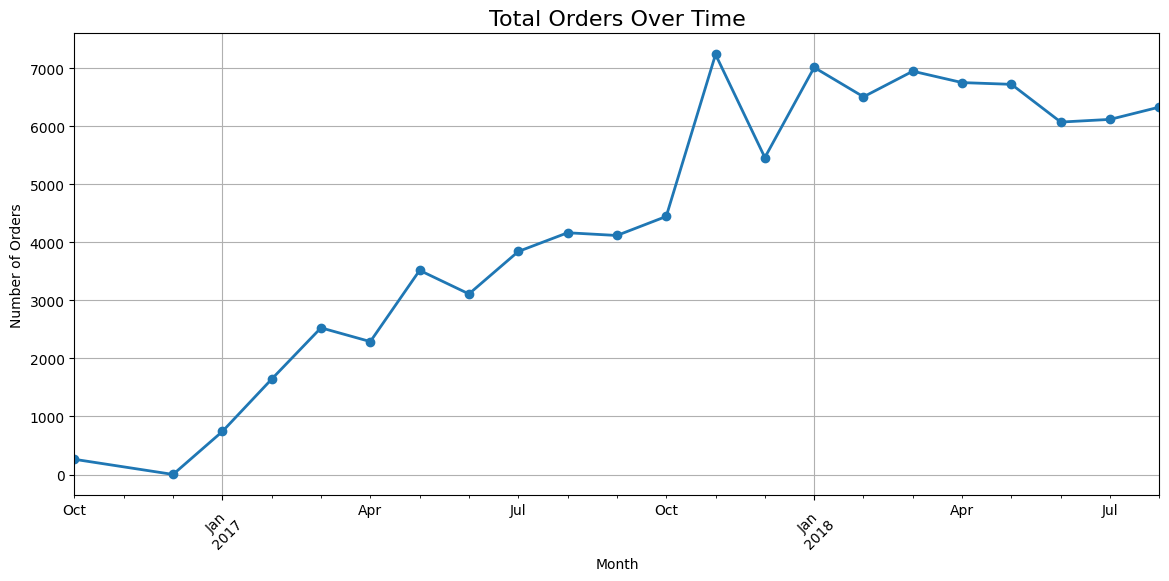

In [ ]:
#Total Orders Over Time
monthly_orders = (
    merged_df.groupby('year_month')['order_id']
    .nunique()
)

plt.figure(figsize=(14,6))

monthly_orders.plot(
    marker='o',
    linewidth=2
)

plt.title('Total Orders Over Time', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Monthly Order Growth %

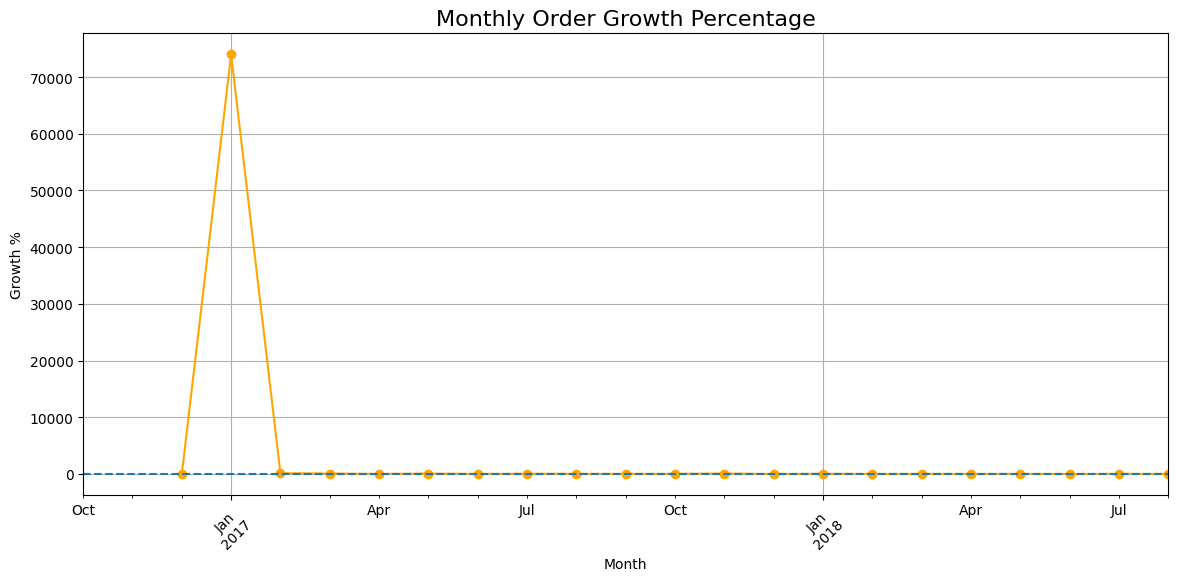

In [ ]:
monthly_growth = (
    monthly_orders.pct_change() * 100
)

plt.figure(figsize=(14,6))

monthly_growth.plot(
    marker='o',
    color='orange'
)

plt.title('Monthly Order Growth Percentage', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Growth %')

plt.axhline(0, linestyle='--')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Year-wise Order Trend

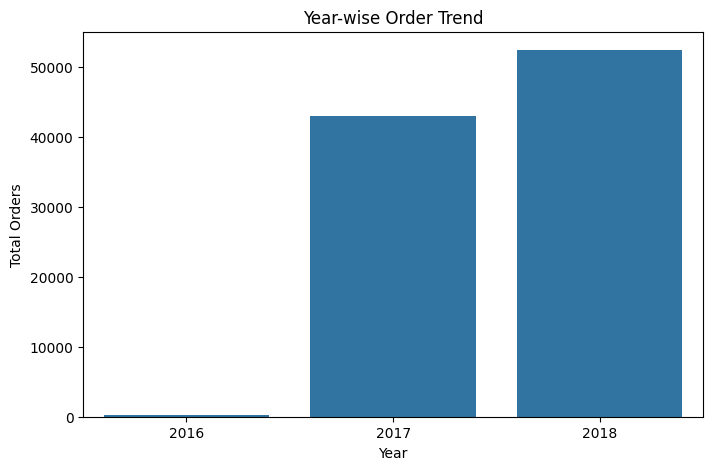

In [ ]:
merged_df['purchase_year'] = (
    merged_df['order_purchase_timestamp'].dt.year
)

yearly_orders = (
    merged_df.groupby('purchase_year')['order_id']
    .nunique()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_orders.index,
    y=yearly_orders.values
)

plt.title('Year-wise Order Trend')
plt.xlabel('Year')
plt.ylabel('Total Orders')

plt.show()

Peak Purchase Months

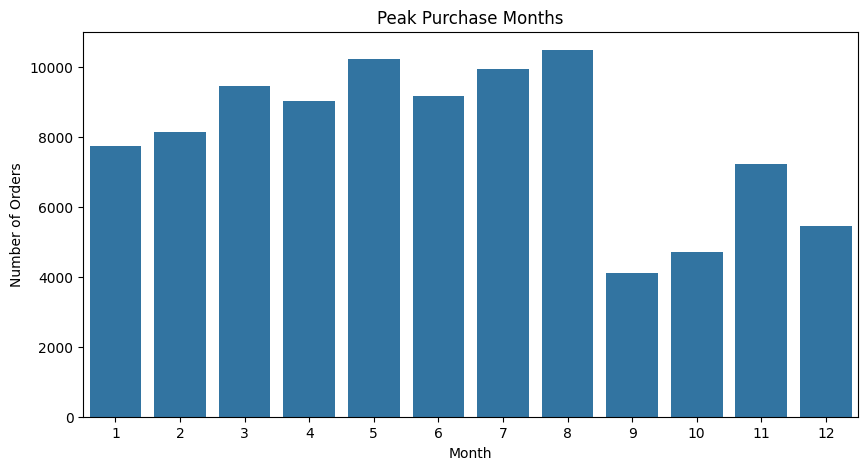

In [ ]:
peak_months = (
    merged_df.groupby('purchase_month')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=peak_months.index,
    y=peak_months.values
)

plt.title('Peak Purchase Months')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.show()

Seasonal Sales Pattern

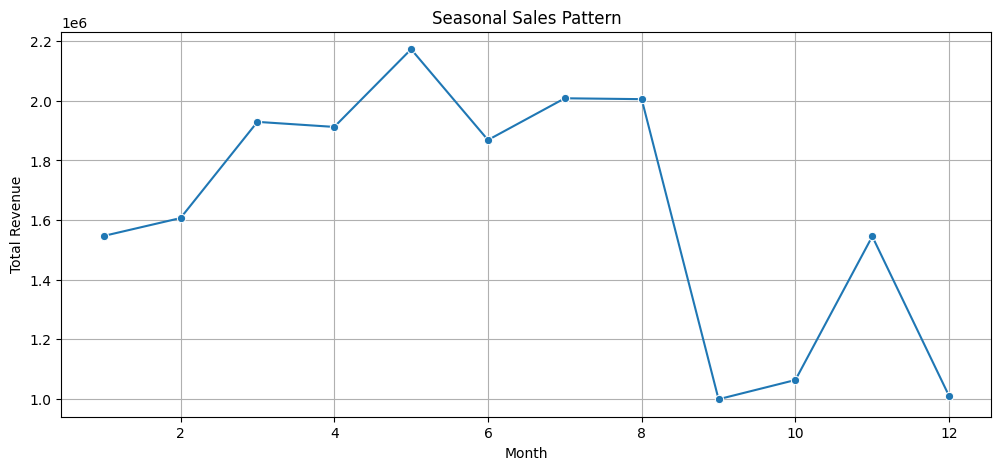

In [ ]:
seasonal_sales = (
    merged_df.groupby('purchase_month')['payment_value']
    .sum()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=seasonal_sales.index,
    y=seasonal_sales.values,
    marker='o'
)

plt.title('Seasonal Sales Pattern')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.grid(True)

plt.show()

Customer Analysis
Total Unique Customers

In [ ]:
total_customers = (
    merged_df['customer_unique_id']
    .nunique()
)

print("Total Unique Customers:", total_customers)

Total Unique Customers: 92746


Repeat vs New Customers

In [ ]:
customer_orders = (
    merged_df.groupby('customer_unique_id')['order_id']
    .nunique()
)

repeat_customers = (
    customer_orders[customer_orders > 1]
    .count()
)

new_customers = (
    customer_orders[customer_orders == 1]
    .count()
)

repeat_percentage = (
    repeat_customers / total_customers
) * 100

new_percentage = (
    new_customers / total_customers
) * 100

print("Repeat Customers:", repeat_customers)
print("New Customers:", new_customers)

print("Repeat Customer %:", round(repeat_percentage,2))
print("New Customer %:", round(new_percentage,2))

Repeat Customers: 2764
New Customers: 89982
Repeat Customer %: 2.98
New Customer %: 97.02


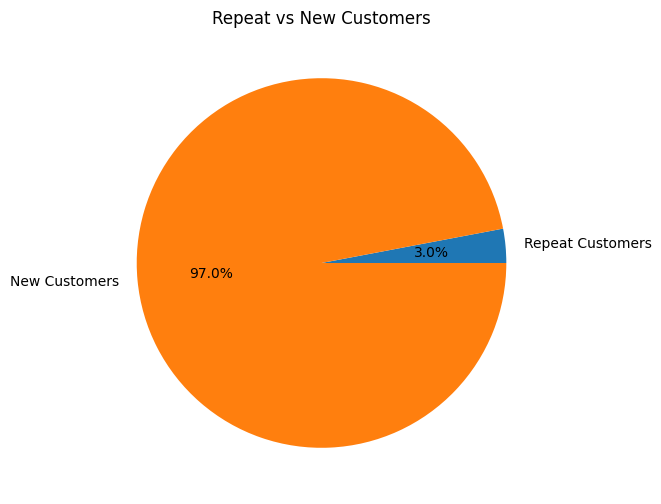

In [ ]:
labels = ['Repeat Customers', 'New Customers']

sizes = [repeat_customers, new_customers]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Repeat vs New Customers')

plt.show()

Orders Per Customer

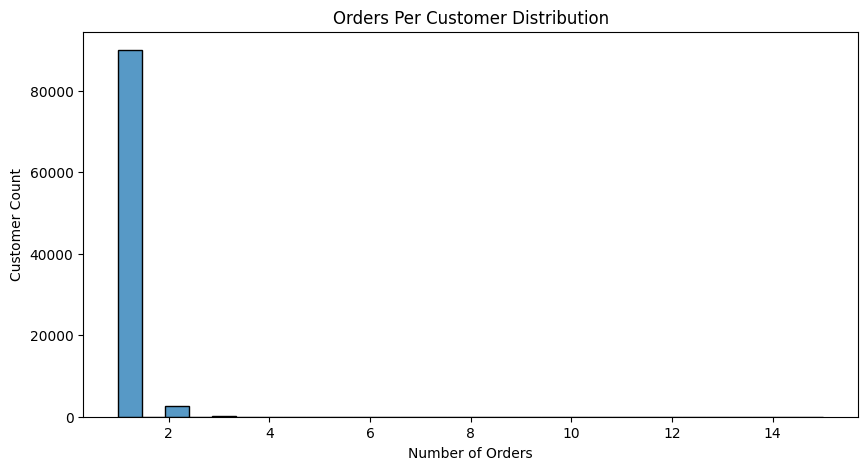

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_orders,
    bins=30
)

plt.title('Orders Per Customer Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Count')

plt.show()

Top Customer States

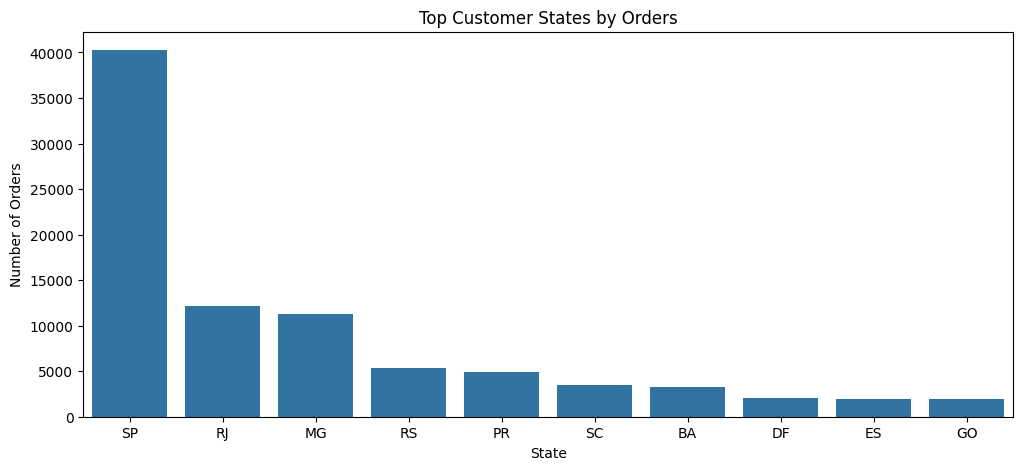

In [ ]:
top_states = (
    merged_df.groupby('customer_state')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title('Top Customer States by Orders')
plt.xlabel('State')
plt.ylabel('Number of Orders')

plt.show()

Customer Distribution by State

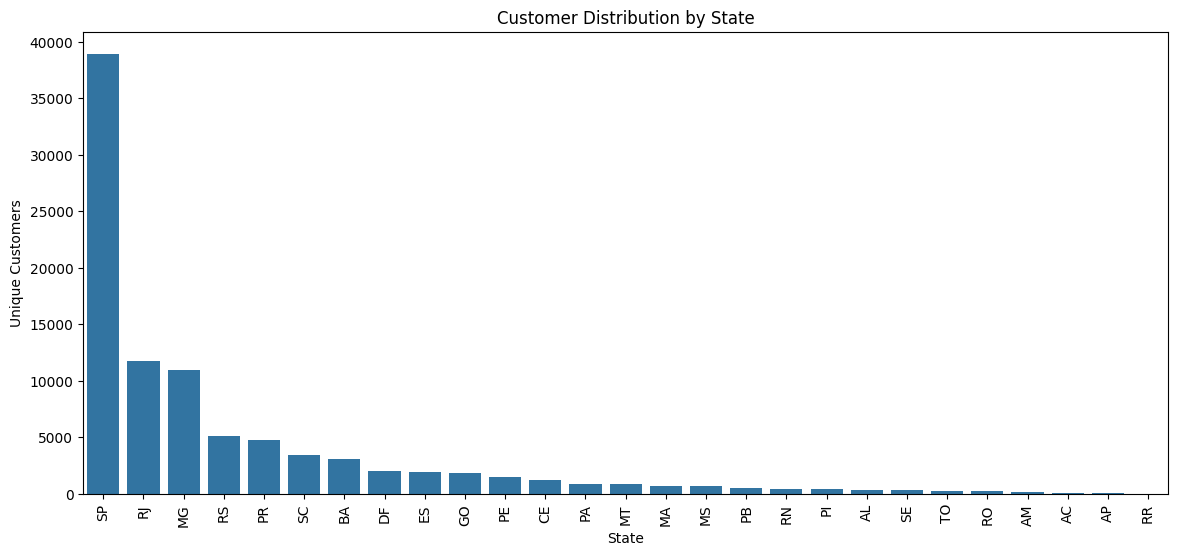

In [ ]:
state_customers = (
    merged_df.groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=state_customers.index,
    y=state_customers.values
)

plt.title('Customer Distribution by State')
plt.xlabel('State')
plt.ylabel('Unique Customers')

plt.xticks(rotation=90)

plt.show()

Total Revenue

In [ ]:
total_revenue = (
    merged_df['payment_value']
    .sum()
)

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 19668897.5


Monthly Revenue Trend

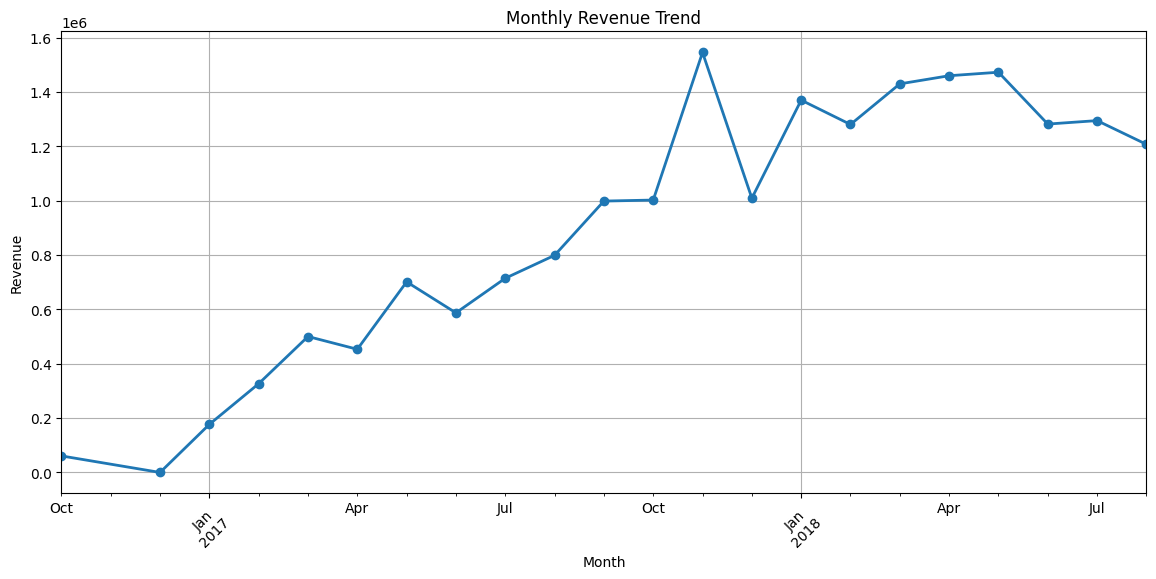

In [ ]:
monthly_revenue = (
    merged_df.groupby('year_month')['payment_value']
    .sum()
)

plt.figure(figsize=(14,6))

monthly_revenue.plot(
    marker='o',
    linewidth=2
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Average Order Value (AOV)

In [ ]:
average_order_value = (
    merged_df.groupby('order_id')['payment_value']
    .sum()
    .mean()
)

print("Average Order Value:", round(average_order_value,2))

Average Order Value: 205.26


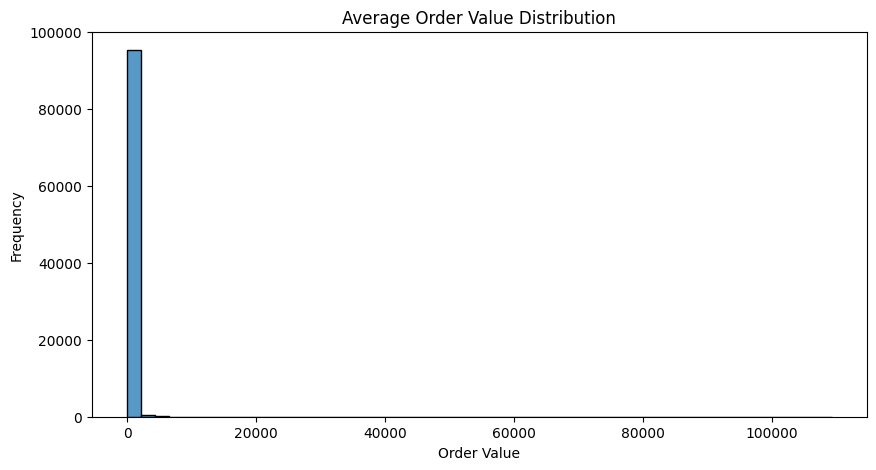

In [ ]:
order_values = (
    merged_df.groupby('order_id')['payment_value']
    .sum()
)

plt.figure(figsize=(10,5))

sns.histplot(
    order_values,
    bins=50
)

plt.title('Average Order Value Distribution')
plt.xlabel('Order Value')
plt.ylabel('Frequency')

plt.show()

Revenue by State

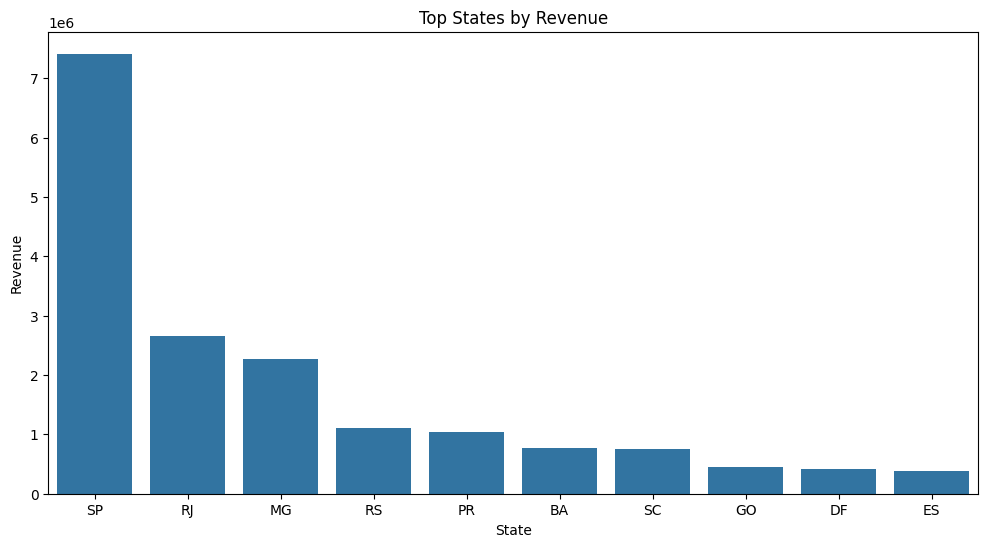

In [ ]:
state_revenue = (
    merged_df.groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_revenue.index,
    y=state_revenue.values
)

plt.title('Top States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

Revenue by Product Category

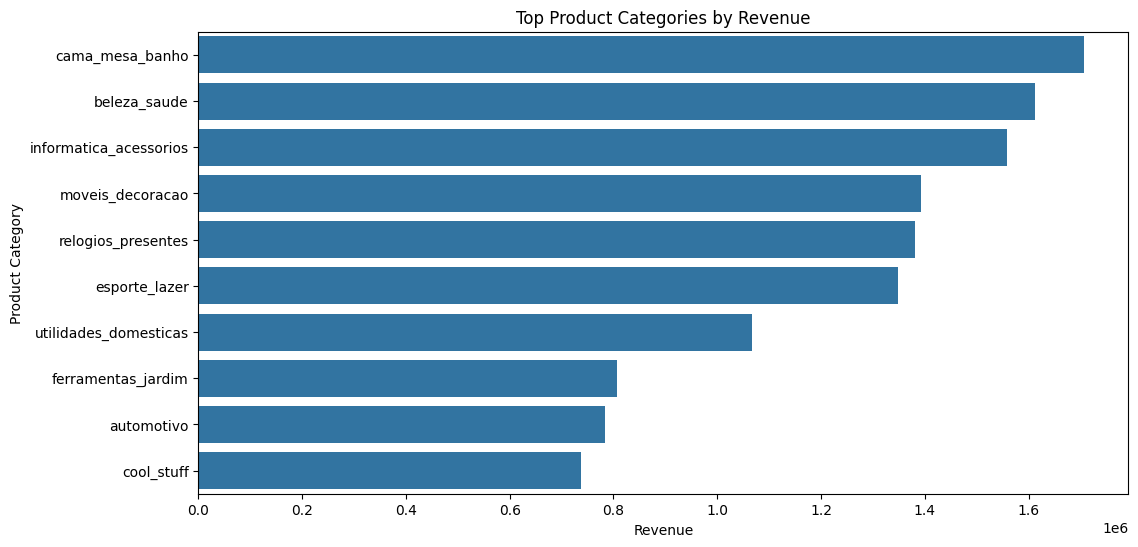

In [ ]:
category_revenue = (
    merged_df.groupby('product_category_name')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title('Top Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')

plt.show()

Revenue vs Orders by Category

In [ ]:
category_analysis = merged_df.groupby(
    'product_category_name'
).agg({
    'order_id':'nunique',
    'payment_value':'sum'
}).sort_values(
    by='payment_value',
    ascending=False
).head(10)

category_analysis

,order_id,payment_value
product_category_name,,
cama_mesa_banho,9177,1707029.45
beleza_saude,8600,1611835.65
informatica_acessorios,6498,1557592.86
moveis_decoracao,6260,1391930.08
relogios_presentes,5452,1380171.71
esporte_lazer,7485,1348464.55
utilidades_domesticas,5709,1067227.12
ferramentas_jardim,3428,807658.18
automotivo,3791,783016.78


Best-Selling Product Categories

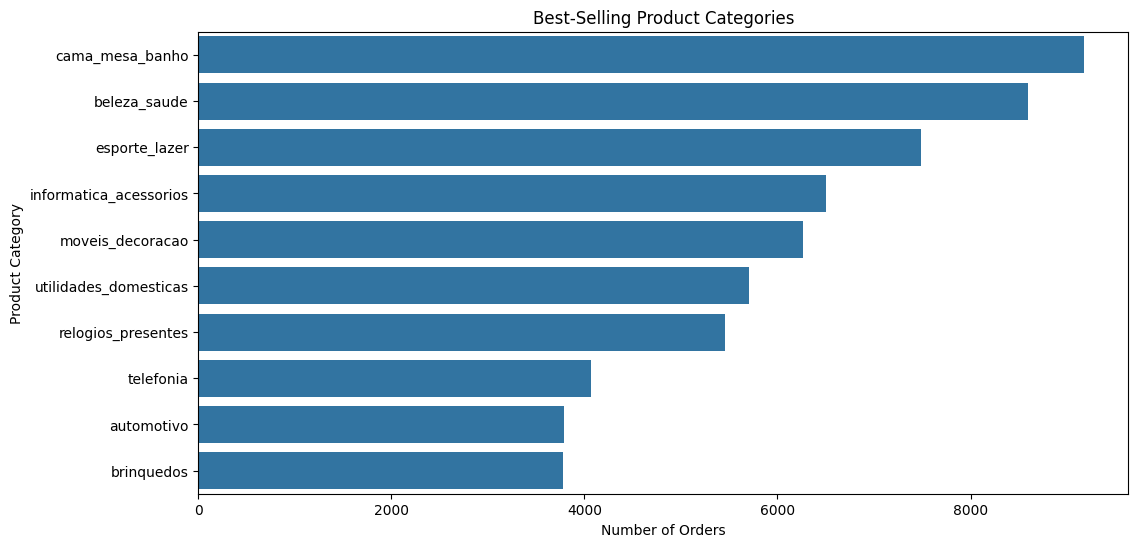

In [ ]:
best_selling_categories = (
    merged_df.groupby('product_category_name')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=best_selling_categories.values,
    y=best_selling_categories.index
)

plt.title('Best-Selling Product Categories')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')

plt.show()

State-wise Best-Selling Categories

In [ ]:
state_category = merged_df.groupby(
    ['customer_state', 'product_category_name']
)['order_id'].nunique().reset_index()

top_state_categories = state_category.loc[
    state_category.groupby('customer_state')['order_id']
    .idxmax()
]

top_state_categories.head(10)

,customer_state,product_category_name,order_id
11,AC,esporte_lazer,9
36,AL,beleza_saude,62
78,AM,beleza_saude,15
112,AP,beleza_saude,10
140,BA,beleza_saude,317
202,CE,beleza_saude,151
257,DF,beleza_saude,218
320,ES,cama_mesa_banho,195
376,GO,beleza_saude,206
434,MA,beleza_saude,81


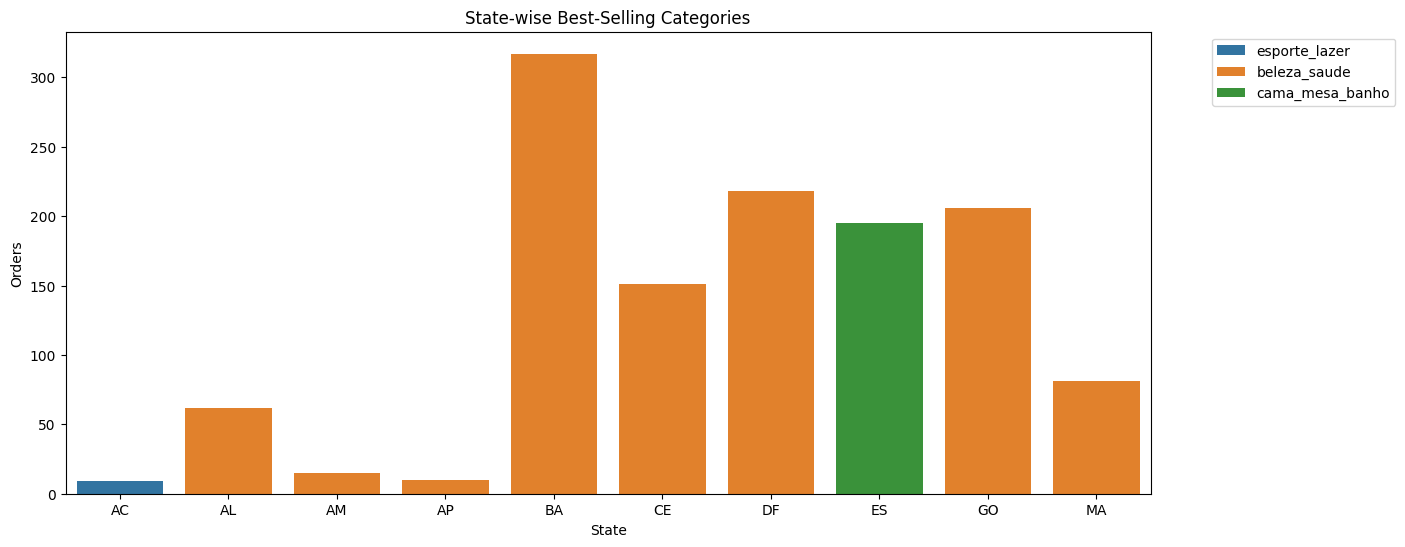

In [ ]:
top_10_states = top_state_categories.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x='customer_state',
    y='order_id',
    hue='product_category_name',
    data=top_10_states
)

plt.title('State-wise Best-Selling Categories')
plt.xlabel('State')
plt.ylabel('Orders')

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.show()

High Revenue vs High Volume Categories

In [ ]:
category_analysis = merged_df.groupby(
    'product_category_name'
).agg({
    'order_id':'nunique',
    'payment_value':'sum'
})

category_analysis.columns = [
    'total_orders',
    'total_revenue'
]

category_analysis = (
    category_analysis
    .sort_values(
        by='total_revenue',
        ascending=False
    )
    .head(10)
)

category_analysis

,total_orders,total_revenue
product_category_name,,
cama_mesa_banho,9177,1707029.45
beleza_saude,8600,1611835.65
informatica_acessorios,6498,1557592.86
moveis_decoracao,6260,1391930.08
relogios_presentes,5452,1380171.71
esporte_lazer,7485,1348464.55
utilidades_domesticas,5709,1067227.12
ferramentas_jardim,3428,807658.18
automotivo,3791,783016.78


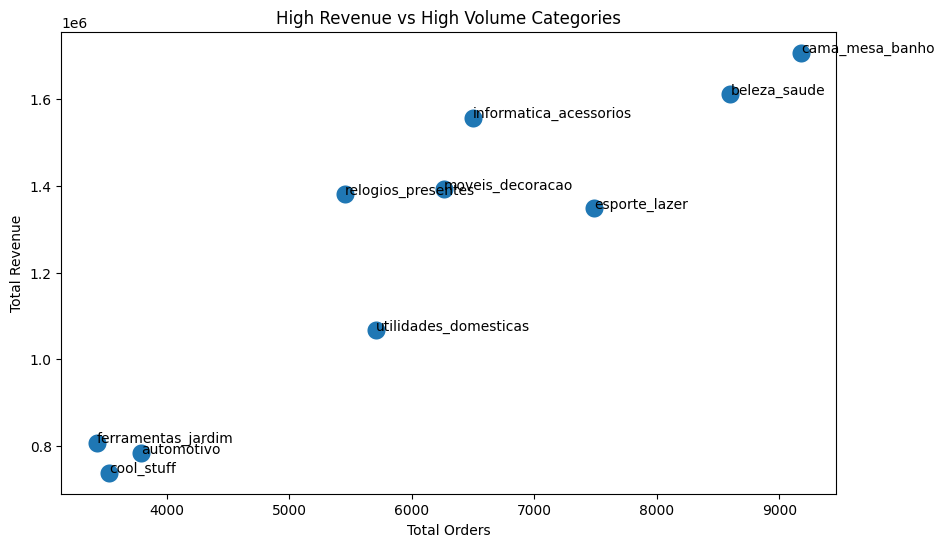

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='total_orders',
    y='total_revenue',
    data=category_analysis,
    s=200
)

for i in range(len(category_analysis)):
    plt.text(
        category_analysis['total_orders'].iloc[i],
        category_analysis['total_revenue'].iloc[i],
        category_analysis.index[i]
    )

plt.title('High Revenue vs High Volume Categories')
plt.xlabel('Total Orders')
plt.ylabel('Total Revenue')

plt.show()

Categories With Poor Reviews

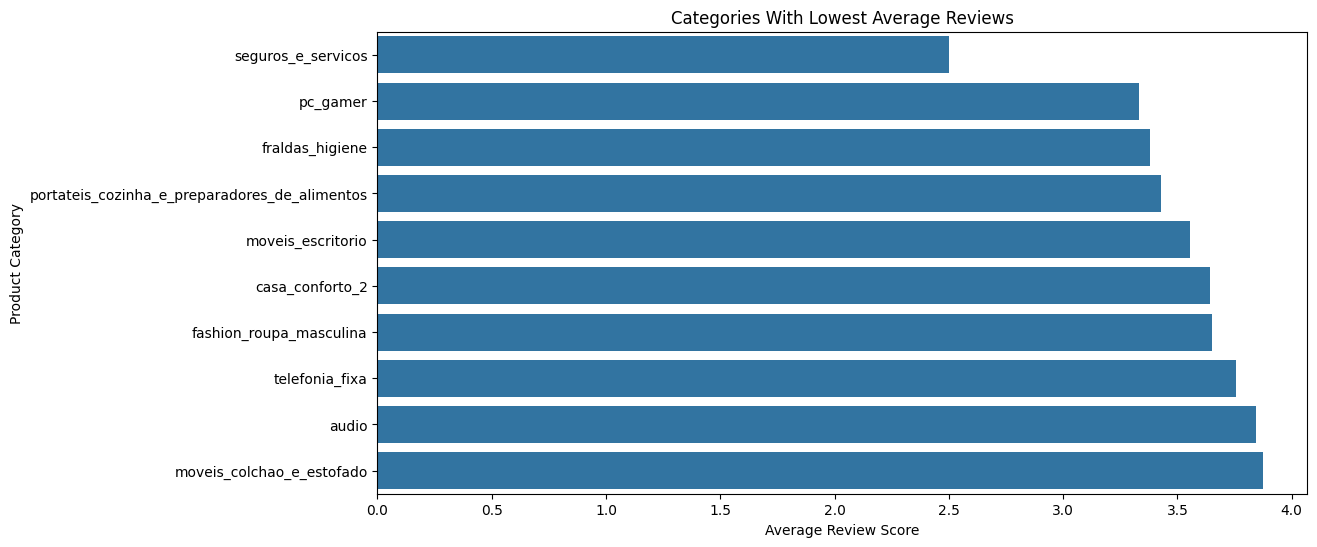

In [ ]:
poor_review_categories = (
    merged_df.groupby('product_category_name')['review_score']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=poor_review_categories.values,
    y=poor_review_categories.index
)

plt.title('Categories With Lowest Average Reviews')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')

plt.show()

Average Product Price by Category

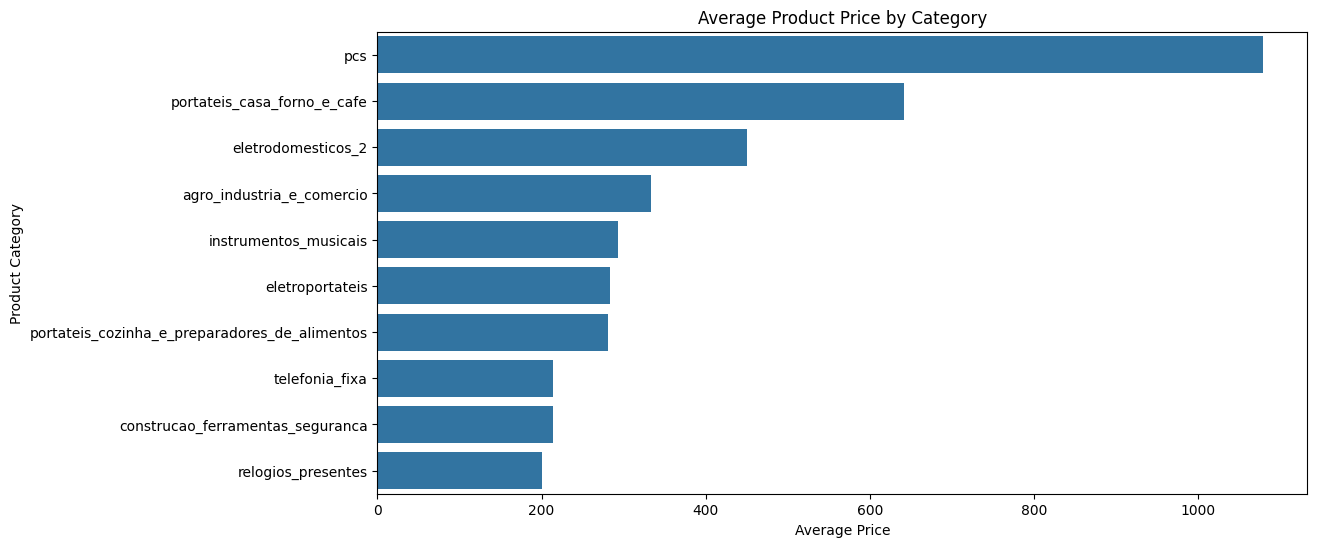

In [ ]:
avg_price_category = (
    merged_df.groupby('product_category_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_price_category.values,
    y=avg_price_category.index
)

plt.title('Average Product Price by Category')
plt.xlabel('Average Price')
plt.ylabel('Product Category')

plt.show()

Payment Analysis

In [ ]:
payment_methods = (
    merged_df['payment_type']
    .value_counts()
)

print(payment_methods)

payment_type
credit_card    84725
boleto         22337
voucher         6135
debit_card      1654
Name: count, dtype: int64


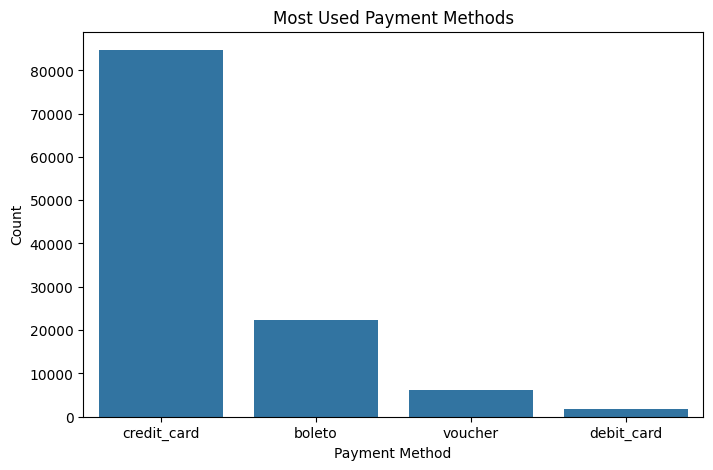

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_methods.index,
    y=payment_methods.values
)

plt.title('Most Used Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.show()

Payment Method Distribution

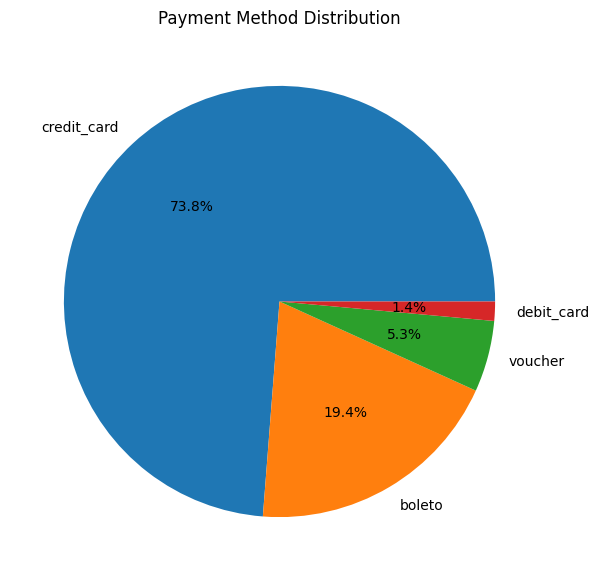

In [ ]:
payment_distribution = (
    merged_df['payment_type']
    .value_counts(normalize=True) * 100
)

plt.figure(figsize=(7,7))

plt.pie(
    payment_distribution.values,
    labels=payment_distribution.index,
    autopct='%1.1f%%'
)

plt.title('Payment Method Distribution')

plt.show()

Installment Trends

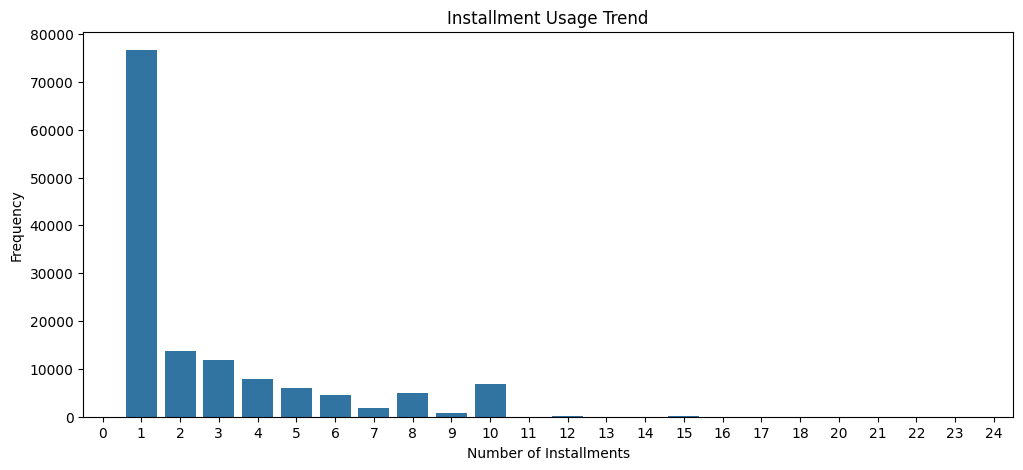

In [ ]:
merged_df = merged_df.merge(payments[['order_id', 'payment_installments']], on='order_id', how='left')
installment_trend = (
    merged_df['payment_installments']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=installment_trend.index,
    y=installment_trend.values
)

plt.title('Installment Usage Trend')
plt.xlabel('Number of Installments')
plt.ylabel('Frequency')

plt.show()

Payment Method vs Order Value

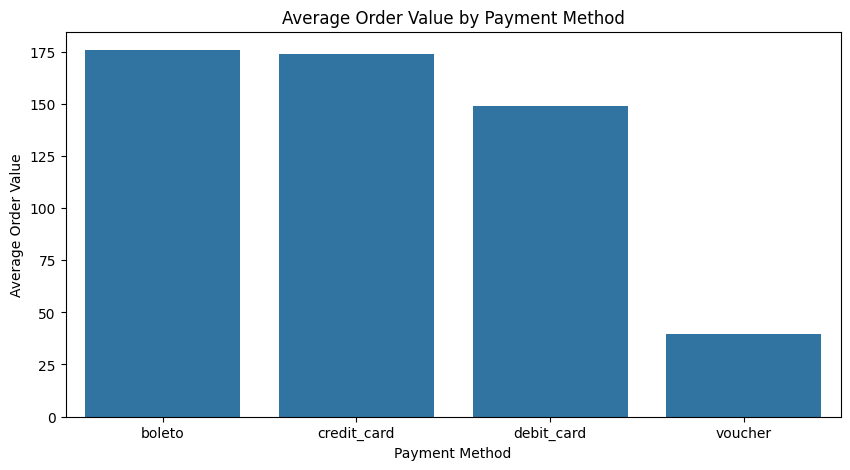

In [ ]:
payment_order_value = (
    merged_df.groupby('payment_type')['payment_value']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=payment_order_value.index,
    y=payment_order_value.values
)

plt.title('Average Order Value by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Order Value')

plt.show()

Average Installments by Category

Average Installments by Category

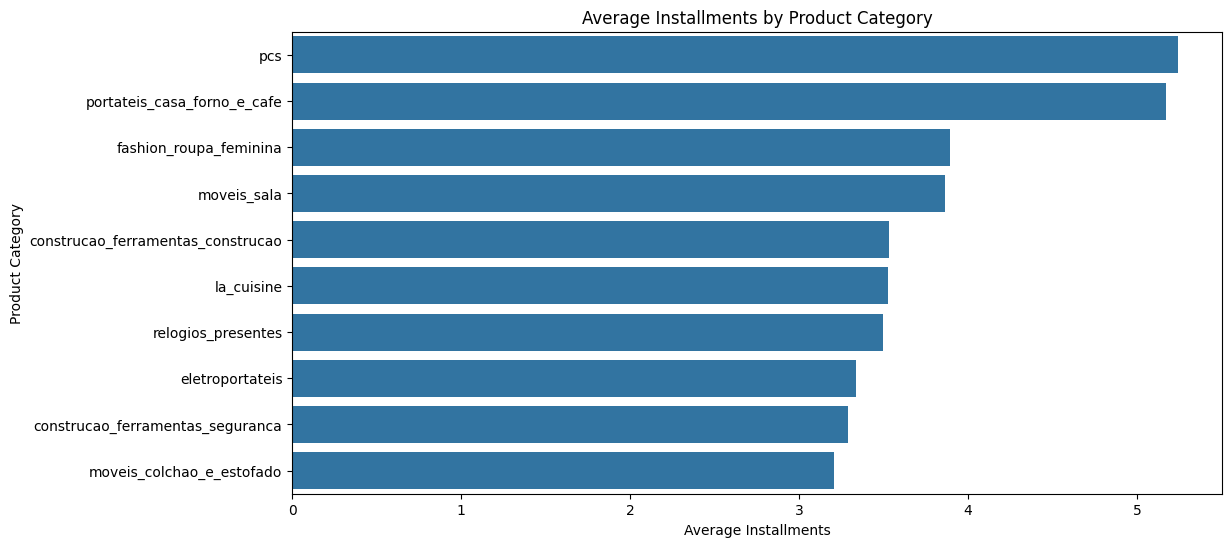

In [ ]:
avg_installments_category = (
    merged_df.groupby('product_category_name')['payment_installments']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_installments_category.values,
    y=avg_installments_category.index
)

plt.title('Average Installments by Product Category')
plt.xlabel('Average Installments')
plt.ylabel('Product Category')

plt.show()

Voucher Usage Patterns

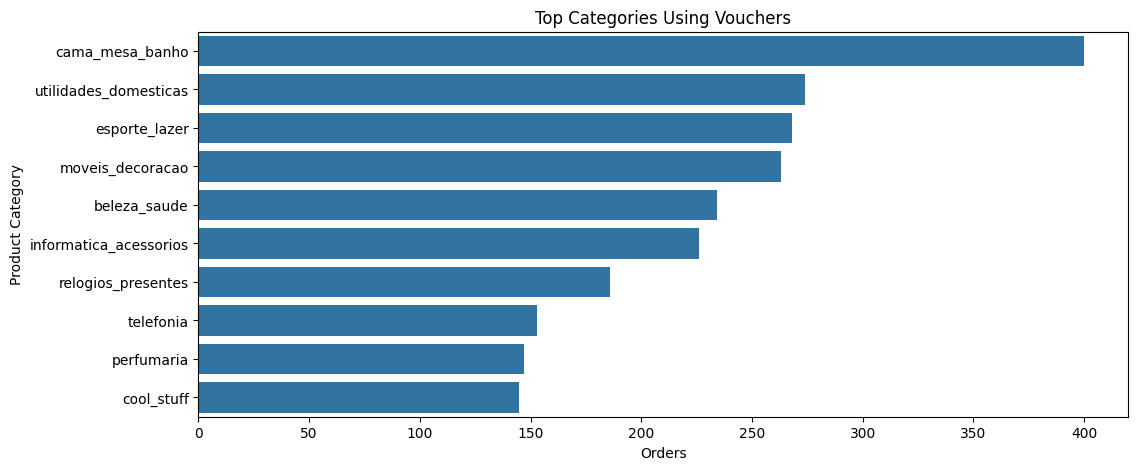

In [ ]:
voucher_usage = merged_df[
    merged_df['payment_type'] == 'voucher'
]

voucher_by_category = (
    voucher_usage.groupby('product_category_name')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=voucher_by_category.values,
    y=voucher_by_category.index
)

plt.title('Top Categories Using Vouchers')
plt.xlabel('Orders')
plt.ylabel('Product Category')

plt.show()

Average Delivery Time

In [ ]:
average_delivery_time = (
    merged_df['delivery_time']
    .mean()
)

print(
    "Average Delivery Time:",
    round(average_delivery_time,2),
    "days"
)

Average Delivery Time: 12.0 days


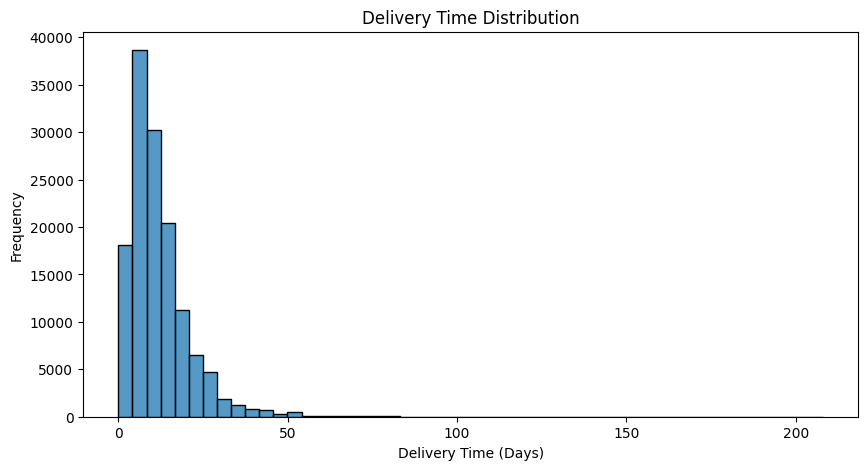

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df['delivery_time'],
    bins=50
)

plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Frequency')

plt.show()

Delivery Delay Distribution

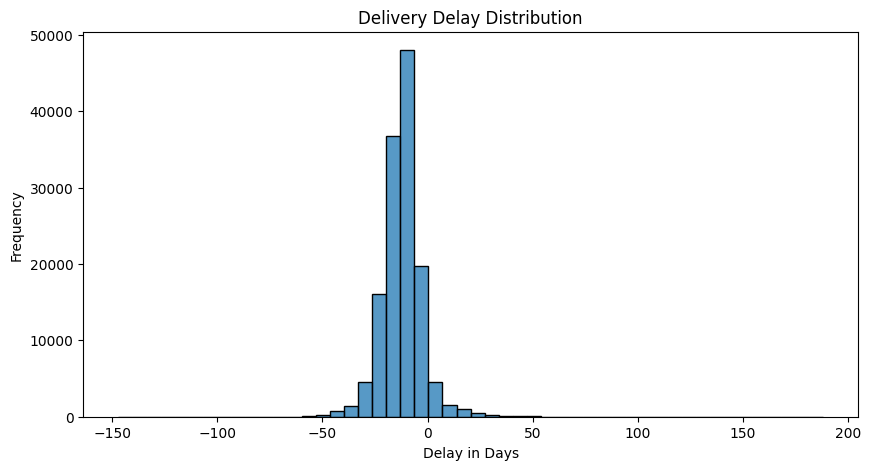

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df['delivery_delay'],
    bins=50
)

plt.title('Delivery Delay Distribution')
plt.xlabel('Delay in Days')
plt.ylabel('Frequency')

plt.show()

On-Time vs Delayed Orders

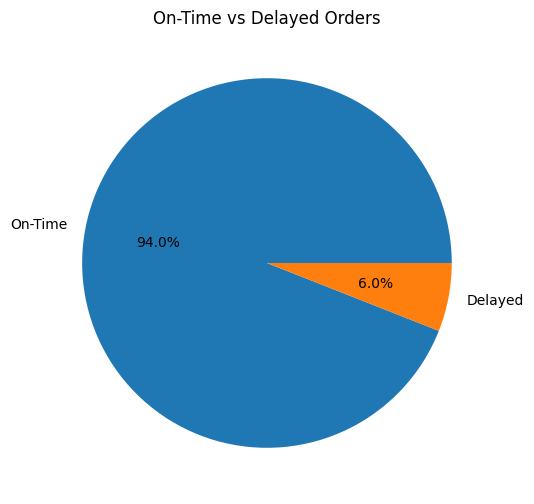

In [ ]:
merged_df['delivery_status'] = np.where(
    merged_df['delivery_delay'] > 0,
    'Delayed',
    'On-Time'
)

delivery_status = (
    merged_df['delivery_status']
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    delivery_status.values,
    labels=delivery_status.index,
    autopct='%1.1f%%'
)

plt.title('On-Time vs Delayed Orders')

plt.show()

Delivery Time by State

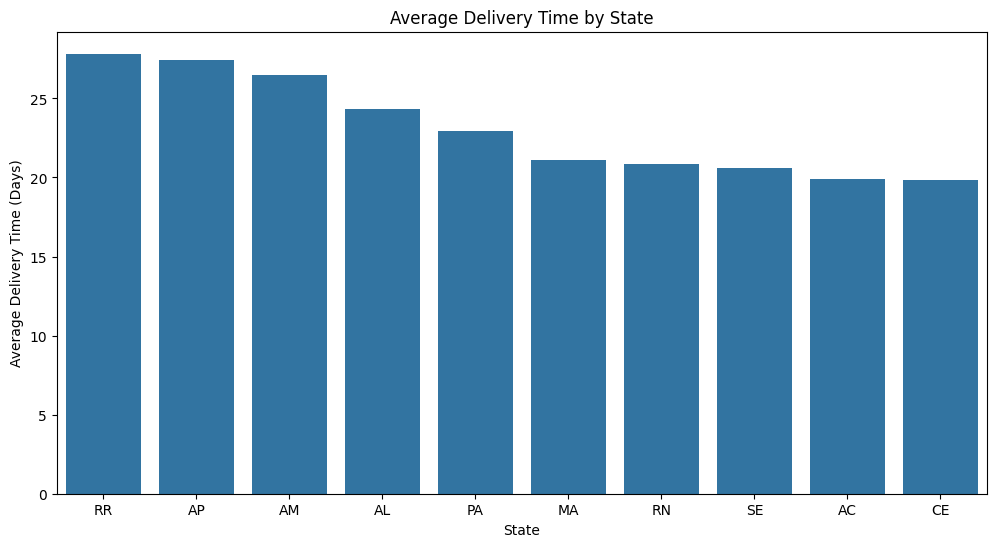

In [ ]:
state_delivery = (
    merged_df.groupby('customer_state')['delivery_time']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_delivery.index,
    y=state_delivery.values
)

plt.title('Average Delivery Time by State')
plt.xlabel('State')
plt.ylabel('Average Delivery Time (Days)')

plt.show()

Delivery Delay by Product Category

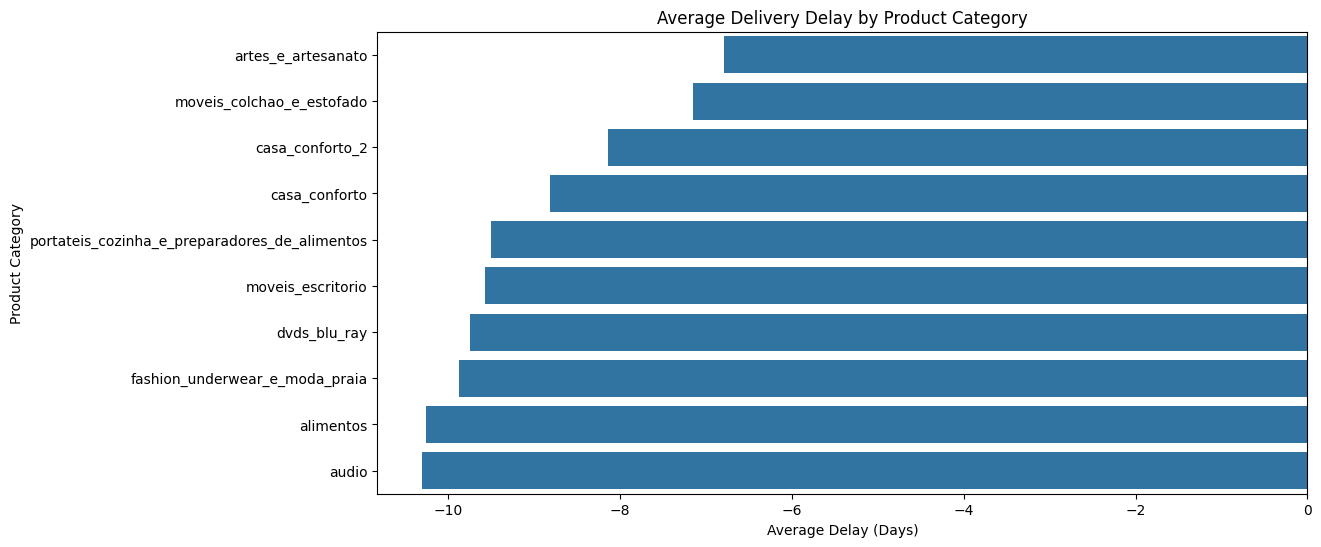

In [ ]:
category_delay = (
    merged_df.groupby('product_category_name')['delivery_delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_delay.values,
    y=category_delay.index
)

plt.title('Average Delivery Delay by Product Category')
plt.xlabel('Average Delay (Days)')
plt.ylabel('Product Category')

plt.show()

Delivery Delay vs Review Score

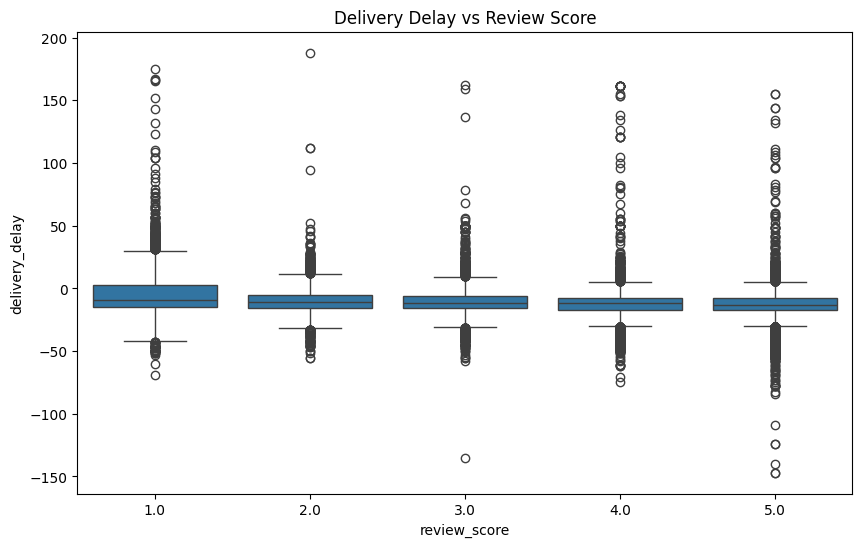

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='review_score',
    y='delivery_delay',
    data=merged_df
)

plt.title('Delivery Delay vs Review Score')

plt.show()

Review Score Distribution

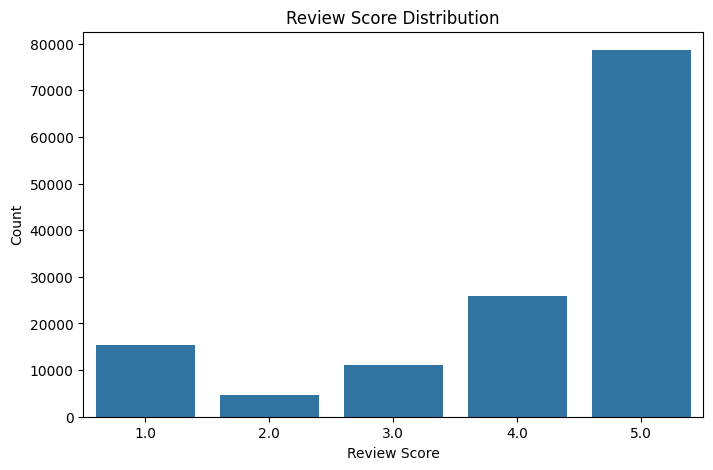

In [ ]:
review_distribution = (
    merged_df['review_score']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=review_distribution.index,
    y=review_distribution.values
)

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')

plt.show()

Average Review Score

In [ ]:
average_review_score = (
    merged_df['review_score']
    .mean()
)

print(
    "Average Review Score:",
    round(average_review_score,2)
)

Average Review Score: 4.09


Review Score vs Delivery Delay

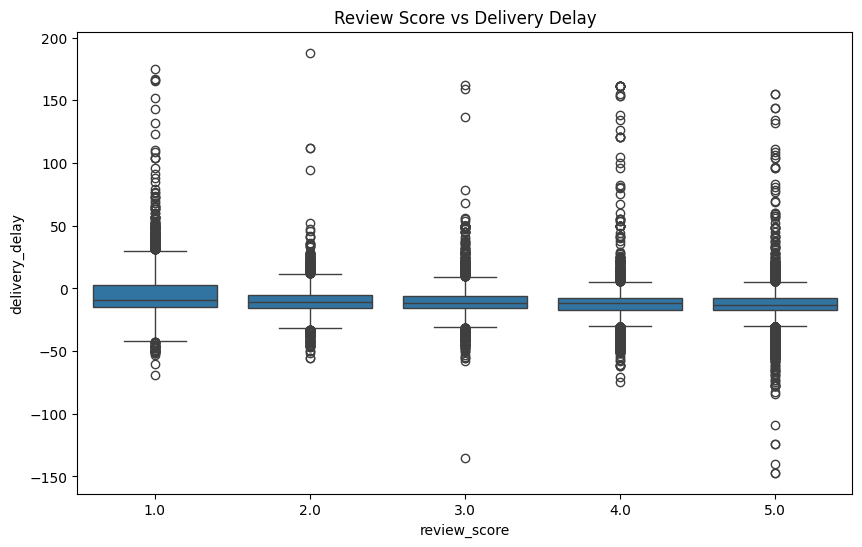

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='review_score',
    y='delivery_delay',
    data=merged_df
)

plt.title('Review Score vs Delivery Delay')

plt.show()

Review Score by Product Category

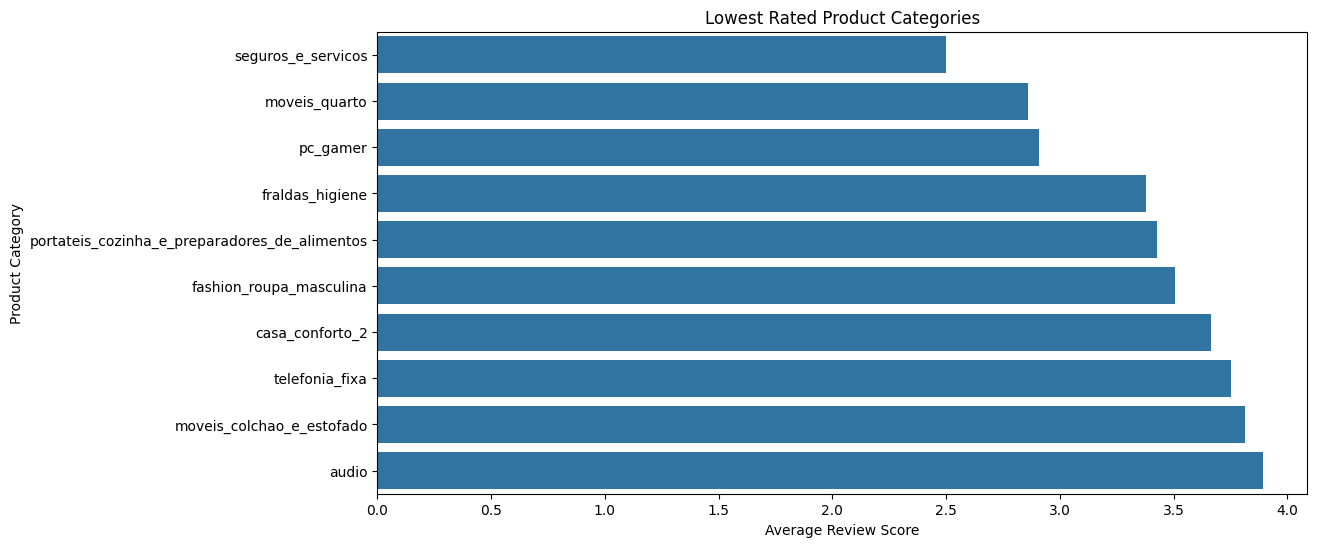

In [ ]:
category_reviews = (
    merged_df.groupby('product_category_name')['review_score']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_reviews.values,
    y=category_reviews.index
)

plt.title('Lowest Rated Product Categories')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')

plt.show()

Review Score by Payment Type

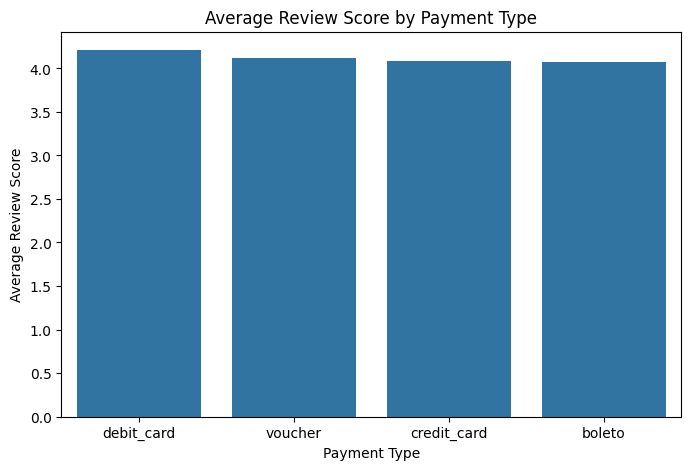

In [ ]:
payment_reviews = (
    merged_df.groupby('payment_type')['review_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_reviews.index,
    y=payment_reviews.values
)

plt.title('Average Review Score by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Average Review Score')

plt.show()

Seller Performance Analysis

In [ ]:
merged_df = merged_df.merge(
    sellers,
    on='seller_id',
    how='left'
)

Top Sellers by Revenue

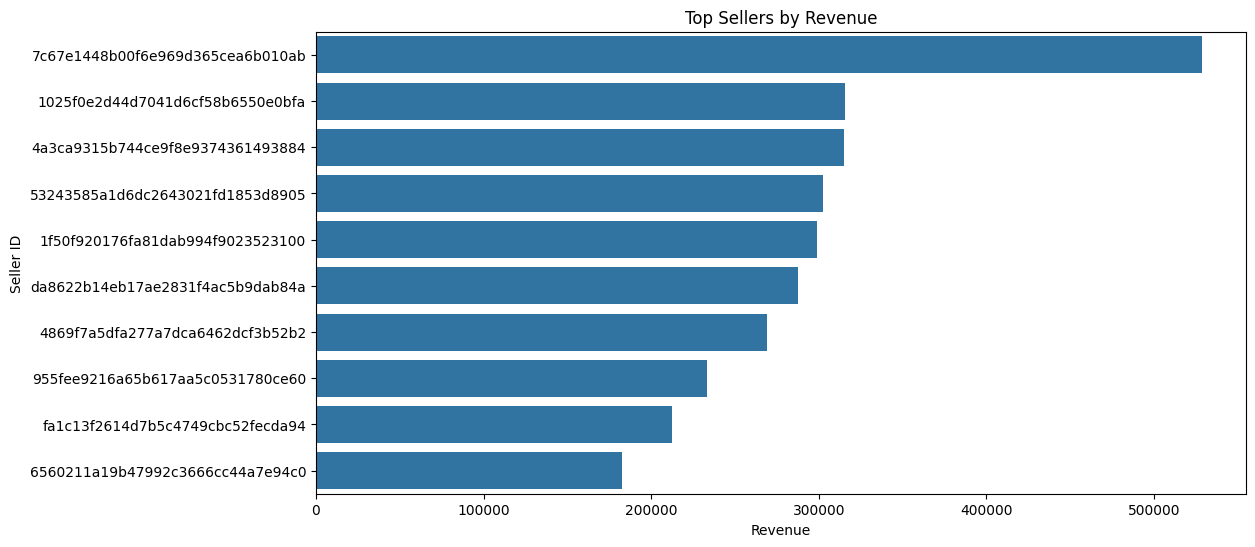

In [ ]:
top_sellers = (
    merged_df.groupby('seller_id')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sellers.values,
    y=top_sellers.index
)

plt.title('Top Sellers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Seller ID')

plt.show()

Seller States

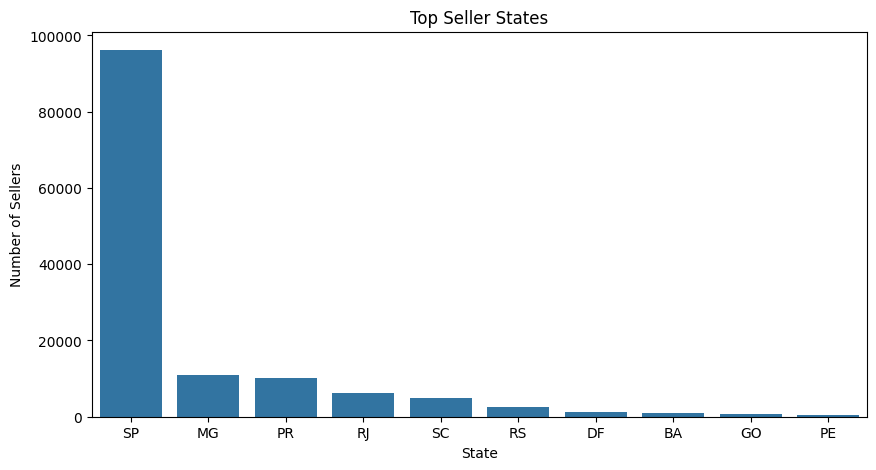

In [ ]:
seller_states = (
    merged_df['seller_state']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=seller_states.index,
    y=seller_states.values
)

plt.title('Top Seller States')
plt.xlabel('State')
plt.ylabel('Number of Sellers')

plt.show()

Seller Performance vs Review Score

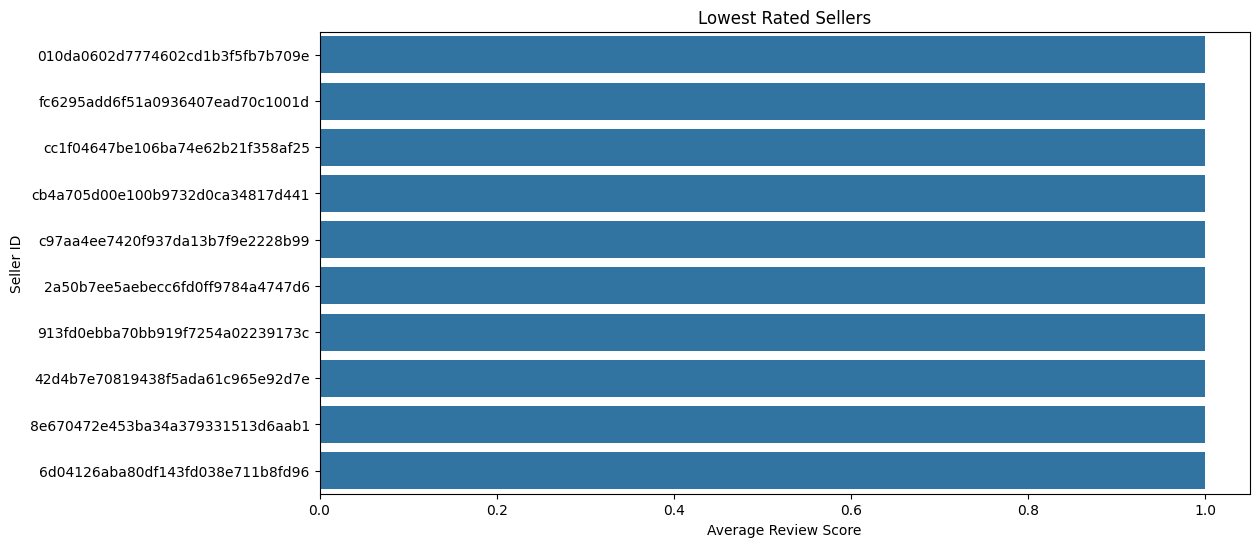

In [ ]:
seller_reviews = (
    merged_df.groupby('seller_id')['review_score']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=seller_reviews.values,
    y=seller_reviews.index
)

plt.title('Lowest Rated Sellers')
plt.xlabel('Average Review Score')
plt.ylabel('Seller ID')

plt.show()

Seller Delivery Efficiency

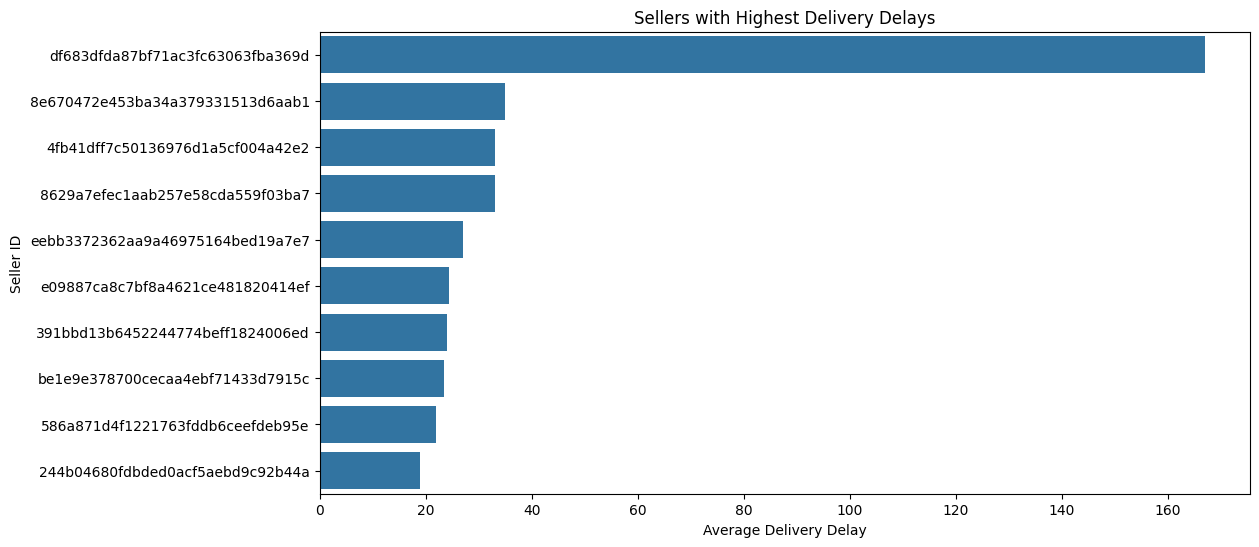

In [ ]:
seller_delivery = (
    merged_df.groupby('seller_id')['delivery_delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=seller_delivery.values,
    y=seller_delivery.index
)

plt.title('Sellers with Highest Delivery Delays')
plt.xlabel('Average Delivery Delay')
plt.ylabel('Seller ID')

plt.show()

Revenue vs Review Score for Sellers

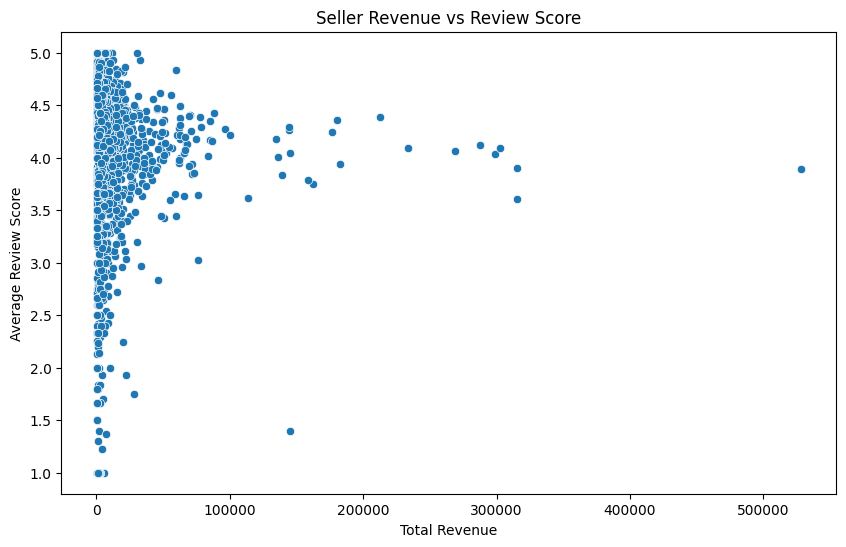

In [ ]:
seller_analysis = merged_df.groupby(
    'seller_id'
).agg({
    'payment_value':'sum',
    'review_score':'mean'
})

seller_analysis.columns = [
    'total_revenue',
    'avg_review_score'
]

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='total_revenue',
    y='avg_review_score',
    data=seller_analysis
)

plt.title('Seller Revenue vs Review Score')
plt.xlabel('Total Revenue')
plt.ylabel('Average Review Score')

plt.show()

Hypothesis Testing & Statistical Analysis

Late deliveries significantly reduce customer review scores.

In [ ]:
on_time_reviews = merged_df[
    merged_df['delivery_delay'] <= 0
]['review_score']

late_reviews = merged_df[
    merged_df['delivery_delay'] > 0
]['review_score']

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    on_time_reviews,
    late_reviews
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 135.94563638066853
P-Value: 0.0


### Interpretation

- The statistical test produced an extremely small p-value (less than 0.05).
- Therefore, the null hypothesis was rejected.
- This confirms that delivery delays have a statistically significant negative impact on customer review scores.
- Customers experiencing delayed deliveries were substantially more likely to provide lower ratings.
- Delivery performance is therefore a critical driver of customer satisfaction within the marketplace.

Higher payment values are associated with better review scores.

In [ ]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    merged_df['payment_value'],
    merged_df['review_score']
)

print("Correlation:", correlation)
print("P-Value:", p_value)

Correlation: -0.07750038346962196
P-Value: 8.237359914927984e-180


### Interpretation

- The correlation between payment value and customer review score was statistically significant but very weak and slightly negative.
- This indicates that higher payment values do not necessarily lead to better customer satisfaction.
- Expensive purchases may create higher customer expectations, which can result in slightly lower satisfaction levels when expectations are not fully met.
- Operational factors such as delivery performance and product experience appear to have a stronger influence on customer reviews than payment value alone.

Delayed orders are more likely to receive low ratings.

In [ ]:
merged_df['low_review'] = np.where(
    merged_df['review_score'] <= 2,
    1,
    0
)

In [ ]:
low_rating_delay = merged_df[
    merged_df['low_review'] == 1
]['delivery_delay']

high_rating_delay = merged_df[
    merged_df['low_review'] == 0
]['delivery_delay']

t_stat, p_value = ttest_ind(
    low_rating_delay,
    high_rating_delay
)

print("P-Value:", p_value)

P-Value: 0.0


### Interpretation

- The statistical test produced a p-value significantly below the 0.05 significance threshold.
- Therefore, the null hypothesis was rejected.
- Delayed orders were significantly more likely to receive low customer ratings compared to on-time deliveries.
- This finding strongly reinforces the relationship between delivery performance and customer satisfaction.
- Improving logistics efficiency could substantially improve customer experience and review outcomes.